# Master ML Pipeline — DBP Forecasting
### Unified & Modular Notebook (v6 Ensemble + TFT v5)

| Pipeline | Models | Framework |
|---|---|---|
| **A — Ensemble Walk-Forward** | GRU · LSTM · GBRT | TensorFlow / Keras |
| **B — TFT v5** | Temporal Fusion Transformer | PyTorch Forecasting |

**How to use:**
1. Edit the **Global Configuration** cell below.
2. Choose `SCALER_TYPE`, `WINDOW_SIZE`, and which `PIPELINES_TO_RUN`.
3. Run all cells (`Kernel → Restart & Run All`).
4. Compare results in the **Comparative Analysis** section at the bottom.


In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                  ★  GLOBAL CONFIGURATION  ★                        ║
# ║  Edit only this cell to reconfigure the entire pipeline.           ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── SCALER ────────────────────────────────────────────────────────────
# Options: "MinMaxScaler" | "StandardScaler" | "RobustScaler"
SCALER_TYPE = "MinMaxScaler"

# ── DATA ──────────────────────────────────────────────────────────────
DATA_PATH = r'C:\Users\lucas\Downloads\Base_DBP.xlsx'

# ── PIPELINE SELECTION ────────────────────────────────────────────────
# Comment out any pipeline you don't want to run.
PIPELINES_TO_RUN = [
    "ensemble_gru_lstm_gbrt",   # Pipeline A — GRU + LSTM + GBRT (Walk-Forward)
    # "tft",                    # Pipeline B — TFT v5  (requires PyTorch Forecasting)
]

# ── TRANSFORMATIONS (Pipeline A only) ────────────────────────────────
# Any subset of: "sazonal_lag12", "log_retorno", "retorno_pct"
TRANSFORMATIONS = ["sazonal_lag12", "log_retorno", "retorno_pct"]

# ── WINDOW SIZE (look-back for GRU / LSTM / GBRT) ────────────────────
WINDOW_SIZE = 14

# ── GRU ARCHITECTURE ─────────────────────────────────────────────────
GRU_CONFIG = dict(
    units_1=32,
    units_2=16,
    dropout=0.35,
    weight_decay=1e-4,
    lr=0.001,
    clipnorm=1.0,
)

# ── LSTM ARCHITECTURE ────────────────────────────────────────────────
LSTM_CONFIG = dict(
    units_1=48,
    units_2=24,
    dropout=0.30,
    weight_decay=1e-4,
    lr=0.001,
    clipnorm=1.0,
)

# ── GBRT (GradientBoosting) ───────────────────────────────────────────
GBRT_CONFIG = dict(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=5,
    loss="huber",
    random_state=42,
)

# ── TRAINING (shared) ────────────────────────────────────────────────
TRAIN_CONFIG = dict(
    batch_size=16,
    epochs_max=150,
    patience=15,
    refit_interval=6,   # walk-forward refit cadence
    train_ratio=0.70,   # initial train split
    val_ratio=0.15,     # held-out val (inside walk-forward)
)

# ── FUTURE FORECAST (Pipeline A) ─────────────────────────────────────
FORECAST_CFG = dict(
    n_months=360,           # 30 years
    refit_interval=12,      # retrain every N future months
    mape_historico=9.20,    # % — used for confidence bands
)

# ── TFT HYPERPARAMETERS (Pipeline B) ─────────────────────────────────
TFT_CONFIG = dict(
    hidden_size=24,
    attention_head_size=2,
    dropout=0.2,
    learning_rate=0.003,    # set None to enable LR Finder
    max_epochs=100,
    max_encoder_length=24,
    min_encoder_length=6,
    max_prediction_length=6,
    batch_size=32,
    use_optuna=True,
    optuna_trials=20,
    use_augmentation=True,
    n_cv_folds=3,
)

# ── SEED ─────────────────────────────────────────────────────────────
SEED = 42

print(f"[CONFIG] Scaler     : {SCALER_TYPE}")
print(f"[CONFIG] Window     : {WINDOW_SIZE}")
print(f"[CONFIG] Pipelines  : {PIPELINES_TO_RUN}")
print(f"[CONFIG] Transforms : {TRANSFORMATIONS}")


[CONFIG] Scaler     : MinMaxScaler
[CONFIG] Window     : 14
[CONFIG] Pipelines  : ['ensemble_gru_lstm_gbrt']
[CONFIG] Transforms : ['sazonal_lag12', 'log_retorno', 'retorno_pct']


In [2]:
# ── Standard / Numerical ─────────────────────────────────────────────
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from copy import deepcopy
from datetime import datetime

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# ── Scikit-learn ──────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score,
)

# ── TensorFlow / Keras (Pipeline A) ──────────────────────────────────
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.regularizers import l2
    tf.random.set_seed(SEED)
    TF_AVAILABLE = True
    print(f"[OK] TensorFlow {tf.__version__}")
except ImportError:
    TF_AVAILABLE = False
    print("[WARN] TensorFlow not found — Pipeline A disabled.")

# ── PyTorch / PyTorch Forecasting (Pipeline B) ───────────────────────
try:
    import torch
    try:
        import lightning.pytorch as pl
        from lightning.pytorch.callbacks import EarlyStopping as PLEarlyStopping
        from lightning.pytorch.callbacks import LearningRateMonitor
    except ImportError:
        import pytorch_lightning as pl
        from pytorch_lightning.callbacks import EarlyStopping as PLEarlyStopping
        from pytorch_lightning.callbacks import LearningRateMonitor

    from pytorch_forecasting import (
        TimeSeriesDataSet, TemporalFusionTransformer, QuantileLoss,
    )
    from pytorch_forecasting.data import GroupNormalizer
    pl.seed_everything(SEED)
    TORCH_AVAILABLE = True
    print(f"[OK] PyTorch {torch.__version__}")
except ImportError:
    TORCH_AVAILABLE = False
    print("[WARN] PyTorch / pytorch-forecasting not found — Pipeline B disabled.")

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
    print(f"[OK] Optuna {optuna.__version__}")
except ImportError:
    OPTUNA_AVAILABLE = False
    print("[INFO] Optuna not found — TFT will use default hyperparameters.")

np.random.seed(SEED)
sns.set_style("whitegrid")


[OK] TensorFlow 2.20.0


Seed set to 42


[OK] PyTorch 2.10.0+cpu
[OK] Optuna 4.7.0


In [3]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  SCALER FACTORY  — single point of truth for all pipelines         ║
# ╚══════════════════════════════════════════════════════════════════════╝

def make_scaler():
    """Return a fresh scaler instance based on global SCALER_TYPE."""
    if SCALER_TYPE == "StandardScaler":
        return StandardScaler()
    elif SCALER_TYPE == "MinMaxScaler":
        return MinMaxScaler(feature_range=(0, 1))
    elif SCALER_TYPE == "RobustScaler":
        return RobustScaler()
    else:
        raise ValueError(f"Unknown SCALER_TYPE: {SCALER_TYPE!r}. "
                         "Choose 'MinMaxScaler', 'StandardScaler', or 'RobustScaler'.")


# ── Shared Metrics ────────────────────────────────────────────────────
def calcular_metricas(y_real, y_pred):
    """Return a dict of RMSE, MAE, MAPE%, R², Bias%, Stability%."""
    y_real = np.array(y_real, dtype=np.float64).flatten()
    y_pred = np.array(y_pred, dtype=np.float64).flatten()
    mask = ~(np.isnan(y_real) | np.isnan(y_pred) |
             np.isinf(y_real) | np.isinf(y_pred))
    y_real, y_pred = y_real[mask], y_pred[mask]
    if len(y_real) < 2:
        return {k: np.nan for k in
                ["RMSE", "MAE", "MAPE_%", "R2", "Vies_%", "Estab_%"]}
    return {
        "RMSE":    np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE":     mean_absolute_error(y_real, y_pred),
        "MAPE_%":  mean_absolute_percentage_error(y_real, y_pred) * 100,
        "R2":      r2_score(y_real, y_pred),
        "Vies_%":  np.mean((y_pred - y_real) / (y_real + 1e-10)) * 100,
        "Estab_%": np.std(np.abs((y_real - y_pred) / (y_real + 1e-10)) * 100),
    }


print(f"[OK] Scaler factory ready — using {SCALER_TYPE}")


[OK] Scaler factory ready — using MinMaxScaler


In [4]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  DATA LOADING                                                       ║
# ╚══════════════════════════════════════════════════════════════════════╝

def carregar_dados(caminho: str) -> pd.DataFrame:
    """Load the Excel time-series file.  Returns sorted DataFrame."""
    try:
        df = pd.read_excel(caminho, usecols=[0, 1])
    except FileNotFoundError:
        df = pd.read_excel("Base_DBP__1_.xlsx", usecols=[0, 1])
    df.columns = ["data", "valores"]
    df = df.dropna(subset=["valores"]).reset_index(drop=True)
    df["data"] = pd.to_datetime(df["data"])
    df = df.sort_values("data").reset_index(drop=True)
    return df


df = carregar_dados(DATA_PATH)
print(f"[DATA] {len(df)} observations  |  "
      f"{df['data'].min():%b/%Y} → {df['data'].max():%b/%Y}")
print(f"[DATA] Value range: R$ {df['valores'].min():,.0f} — R$ {df['valores'].max():,.0f}")
df.tail(3)


[DATA] 253 observations  |  Aug/2003 → Aug/2024
[DATA] Value range: R$ 8,630 — R$ 110,107


,data,valores
250,2024-06-01,94632.5
251,2024-07-01,73375.9
252,2024-08-01,72622.9


In [5]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  TIME-SERIES TRANSFORMATIONS  (Pipeline A)                          ║
# ╚══════════════════════════════════════════════════════════════════════╝

def criar_serie_sazonal(valores):
    v = np.array(valores, dtype=np.float64)
    return v[12:] / v[:-12] - 1, 12

def criar_serie_logret(valores):
    v = np.array(valores, dtype=np.float64)
    return np.diff(np.log(v)), 1

def criar_serie_retpct(valores):
    v = np.array(valores, dtype=np.float64)
    return np.diff(v) / v[:-1] * 100, 1

def reconstruir_sazonal(pred, ref): return ref * (1 + pred)
def reconstruir_logret(pred, ref):  return ref * np.exp(pred)
def reconstruir_retpct(pred, ref):  return ref * (1 + pred / 100)

_TRANSFORM_MAP = {
    "sazonal_lag12": (criar_serie_sazonal, reconstruir_sazonal),
    "log_retorno":   (criar_serie_logret,  reconstruir_logret),
    "retorno_pct":   (criar_serie_retpct,  reconstruir_retpct),
}
_LABEL_MAP = {
    "sazonal_lag12": "Sazonal Lag-12",
    "log_retorno":   "Log-Retorno",
    "retorno_pct":   "Retorno %",
}

def criar_janelas(dados, janela):
    X, y = [], []
    for i in range(janela, len(dados)):
        X.append(dados[i - janela:i, 0])
        y.append(dados[i, 0])
    return np.array(X), np.array(y)

print("[OK] Transformation helpers loaded.")


[OK] Transformation helpers loaded.


In [6]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  NEURAL NETWORK MODEL BUILDERS  (Pipeline A)                        ║
# ║  Architecture driven by GRU_CONFIG / LSTM_CONFIG from config cell. ║
# ╚══════════════════════════════════════════════════════════════════════╝

def construir_gru(janela: int) -> "Sequential":
    cfg = GRU_CONFIG
    model = Sequential([
        GRU(cfg["units_1"], return_sequences=True,
            kernel_regularizer=l2(cfg["weight_decay"]),
            recurrent_regularizer=l2(cfg["weight_decay"]),
            input_shape=(janela, 1)),
        Dropout(cfg["dropout"]),
        GRU(cfg["units_2"], return_sequences=False,
            kernel_regularizer=l2(cfg["weight_decay"]),
            recurrent_regularizer=l2(cfg["weight_decay"])),
        Dropout(cfg["dropout"]),
        Dense(8, activation="relu", kernel_regularizer=l2(cfg["weight_decay"])),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=cfg["lr"],
                                 clipnorm=cfg["clipnorm"]),
                  loss="huber")
    return model


def construir_lstm(janela: int) -> "Sequential":
    cfg = LSTM_CONFIG
    model = Sequential([
        LSTM(cfg["units_1"], return_sequences=True,
             kernel_regularizer=l2(cfg["weight_decay"]),
             recurrent_regularizer=l2(cfg["weight_decay"]),
             input_shape=(janela, 1)),
        Dropout(cfg["dropout"]),
        LSTM(cfg["units_2"], return_sequences=False,
             kernel_regularizer=l2(cfg["weight_decay"]),
             recurrent_regularizer=l2(cfg["weight_decay"])),
        Dropout(cfg["dropout"]),
        Dense(16, activation="relu", kernel_regularizer=l2(cfg["weight_decay"])),
        Dense(8,  activation="relu", kernel_regularizer=l2(cfg["weight_decay"])),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=cfg["lr"],
                                 clipnorm=cfg["clipnorm"]),
                  loss="huber")
    return model


def treinar_rede(model, X_tr, y_tr, X_val, y_val):
    tc = TRAIN_CONFIG
    cbs = [
        EarlyStopping(monitor="val_loss", patience=tc["patience"],
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=tc["patience"] // 3, min_lr=1e-6, verbose=0),
    ]
    model.fit(X_tr, y_tr,
              validation_data=(X_val, y_val),
              epochs=tc["epochs_max"],
              batch_size=tc["batch_size"],
              callbacks=cbs, verbose=0, shuffle=False)
    return model


def treinar_gbrt(X_2d, y):
    model = GradientBoostingRegressor(**GBRT_CONFIG)
    model.fit(X_2d, y)
    return model


print(f"[OK] Model builders loaded — GRU {GRU_CONFIG['units_1']}/{GRU_CONFIG['units_2']} "
      f"| LSTM {LSTM_CONFIG['units_1']}/{LSTM_CONFIG['units_2']}")


[OK] Model builders loaded — GRU 32/16 | LSTM 48/24


In [7]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  WALK-FORWARD ENGINE  (Pipeline A)                                  ║
# ║  SCALER_TYPE is injected via make_scaler() — swap in config cell.  ║
# ╚══════════════════════════════════════════════════════════════════════╝

def walk_forward(df: pd.DataFrame, modo: str) -> dict:
    """
    Walk-forward evaluation for one transformation mode.
    Returns dict keyed by model name with pred / real / indices arrays.
    Scaler is created fresh from make_scaler() at each walk step.
    """
    valores = df["valores"].values.astype(np.float64)
    n = len(valores)
    inicio = int(n * TRAIN_CONFIG["train_ratio"])
    janela = WINDOW_SIZE
    criar_serie, reconstruir_fn = _TRANSFORM_MAP[modo]

    print(f"\n  [{_LABEL_MAP[modo]}]  n={n}  test_start={inicio}  "
          f"window={janela}  scaler={SCALER_TYPE}")

    res = {m: {"pred": [], "real": [], "indices": []}
           for m in ("GRU", "LSTM", "Ensemble")}
    erros_gru, erros_lstm, erros_gbrt = [], [], []
    model_gru = model_lstm = model_gbrt = None
    passos_refit = TRAIN_CONFIG["refit_interval"]  # force first fit

    JANELA_PESO = 6  # adaptive ensemble window

    for t in range(inicio, n):
        brutos = valores[:t]
        if len(brutos) < janela + 15:
            continue

        serie, offset = criar_serie(brutos)
        if len(serie) < janela + 5:
            continue

        # ── scaler fit on train split only ───────────────────────────
        n_val = max(int(len(serie) * TRAIN_CONFIG["val_ratio"]), 2)
        n_train = len(serie) - n_val

        scaler = make_scaler()
        scaler.fit(serie[:n_train].reshape(-1, 1))
        scaled = scaler.transform(serie.reshape(-1, 1))

        X_seq, y_seq = criar_janelas(scaled, janela)
        X_3d = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

        n_jt = max(n_train - janela, 1)
        X_3d_tr, y_tr = X_3d[:n_jt], y_seq[:n_jt]
        X_3d_val, y_val = X_3d[n_jt:], y_seq[n_jt:]
        X_2d_tr = X_seq[:n_jt]

        if len(X_3d_val) < 1:
            X_3d_val, y_val = X_3d_tr[-2:], y_tr[-2:]
            X_3d_tr, y_tr = X_3d_tr[:-2], y_tr[:-2]
        if len(X_3d_tr) < 2:
            continue

        # ── refit ────────────────────────────────────────────────────
        if passos_refit >= TRAIN_CONFIG["refit_interval"] or model_gru is None:
            tf.keras.backend.clear_session()
            tf.random.set_seed(SEED)
            model_gru  = treinar_rede(construir_gru(janela),  X_3d_tr, y_tr, X_3d_val, y_val)
            model_lstm = treinar_rede(construir_lstm(janela), X_3d_tr, y_tr, X_3d_val, y_val)
            model_gbrt = treinar_gbrt(X_2d_tr, y_seq[:n_jt])
            passos_refit = 0
            print(f"    ↺ refit t={t} ({df['data'].iloc[t]:%Y-%m}) "
                  f"| train={len(X_3d_tr)} val={len(X_3d_val)}")

        # ── predict ──────────────────────────────────────────────────
        ult_3d = scaled[-janela:].reshape(1, janela, 1)
        ult_2d = scaled[-janela:].flatten().reshape(1, -1)

        def inv(x):
            return scaler.inverse_transform([[x]])[0, 0]

        p_gru  = inv(model_gru.predict(ult_3d, verbose=0)[0, 0])
        p_lstm = inv(model_lstm.predict(ult_3d, verbose=0)[0, 0])
        p_gbrt = inv(model_gbrt.predict(ult_2d)[0])

        val_ref = brutos[-12] if modo == "sazonal_lag12" else brutos[-1]
        v_gru  = reconstruir_fn(p_gru,  val_ref)
        v_lstm = reconstruir_fn(p_lstm, val_ref)
        v_gbrt = reconstruir_fn(p_gbrt, val_ref)

        # ── adaptive ensemble weights ────────────────────────────────
        if len(erros_gru) >= JANELA_PESO:
            w = lambda errs: 1.0 / (np.mean(np.abs(errs[-JANELA_PESO:])) + 1e-10)
            wg, wl, wb = w(erros_gru), w(erros_lstm), w(erros_gbrt)
            tot = wg + wl + wb
            wg, wl, wb = max(wg/tot, 0.10), max(wl/tot, 0.10), max(wb/tot, 0.10)
            tot = wg + wl + wb
            wg, wl, wb = wg/tot, wl/tot, wb/tot
        else:
            wg = wl = wb = 1/3

        v_ens = wg * v_gru + wl * v_lstm + wb * v_gbrt
        real = valores[t]

        for nome, pred in [("GRU", v_gru), ("LSTM", v_lstm), ("Ensemble", v_ens)]:
            res[nome]["pred"].append(pred)
            res[nome]["real"].append(real)
            res[nome]["indices"].append(t)

        erros_gru.append(v_gru  - real)
        erros_lstm.append(v_lstm - real)
        erros_gbrt.append(v_gbrt - real)
        passos_refit += 1

        # ── progress log ─────────────────────────────────────────────
        n_done = len(res["Ensemble"]["pred"])
        if n_done % 12 == 0 and n_done > 0:
            me = calcular_metricas(res["Ensemble"]["real"], res["Ensemble"]["pred"])
            print(f"    step={n_done:>3d} | Ens R²={me['R2']:.4f} | "
                  f"wts GRU={wg:.2f} LSTM={wl:.2f} GBRT={wb:.2f}")

    for nome in res:
        for k in res[nome]:
            res[nome][k] = np.array(res[nome][k])
    return res


print("[OK] Walk-forward engine ready.")


[OK] Walk-forward engine ready.


In [8]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  FUTURE FORECAST ENGINE  (Pipeline A)                               ║
# ║  Uses best mode (sazonal_lag12) + Ensemble (GRU+LSTM+GBRT).        ║
# ╚══════════════════════════════════════════════════════════════════════╝

def prever_futuro(df: pd.DataFrame) -> dict:
    cfg = FORECAST_CFG
    n_meses = cfg["n_months"]
    janela = WINDOW_SIZE
    criar_serie = criar_serie_sazonal
    reconstruir_fn = reconstruir_sazonal

    print(f"\n{'█'*70}")
    print(f"  FUTURE FORECAST — {n_meses} months ({n_meses//12} years)")
    print(f"  Scaler: {SCALER_TYPE}  |  Window: {janela}")
    print(f"{'█'*70}")

    valores_hist = df["valores"].values.astype(np.float64).tolist()
    ultima_data = df["data"].iloc[-1]
    datas_futuras = pd.date_range(
        start=ultima_data + pd.DateOffset(months=1),
        periods=n_meses, freq="MS",
    )

    def _fit_and_train(valores_arr):
        serie, _ = criar_serie(valores_arr)
        n_val = max(int(len(serie) * 0.15), 2)
        n_train = len(serie) - n_val
        sc = make_scaler()
        sc.fit(serie[:n_train].reshape(-1, 1))
        scaled = sc.transform(serie.reshape(-1, 1))
        X_seq, y_seq = criar_janelas(scaled, janela)
        X_3d = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)
        n_jt = max(n_train - janela, 1)
        X_tr, y_tr = X_3d[:n_jt], y_seq[:n_jt]
        X_val, y_val = X_3d[n_jt:], y_seq[n_jt:]
        if len(X_val) < 1:
            X_val, y_val = X_tr[-2:], y_tr[-2:]
            X_tr, y_tr = X_tr[:-2], y_tr[:-2]
        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)
        mg  = treinar_rede(construir_gru(janela),  X_tr, y_tr, X_val, y_val)
        ml  = treinar_rede(construir_lstm(janela), X_tr, y_tr, X_val, y_val)
        mb  = treinar_gbrt(X_seq[:n_jt], y_seq[:n_jt])
        return mg, ml, mb, sc, scaled

    model_gru, model_lstm, model_gbrt, sc, scaled = _fit_and_train(
        np.array(valores_hist))
    print(f"  [OK] Initial fit on {len(valores_hist)} months.")

    previsoes = []
    p_gru_l, p_lstm_l, p_gbrt_l = [], [], []

    for i in range(n_meses):
        arr = np.array(valores_hist, dtype=np.float64)
        serie, _ = criar_serie(arr)
        n_val = max(int(len(serie) * 0.15), 2)
        n_train = len(serie) - n_val
        sc = make_scaler()
        sc.fit(serie[:n_train].reshape(-1, 1))
        scaled = sc.transform(serie.reshape(-1, 1))

        if i > 0 and i % cfg["refit_interval"] == 0:
            model_gru, model_lstm, model_gbrt, sc, scaled = _fit_and_train(arr)
            print(f"  ↺ refit month {i} ({datas_futuras[i]:%Y-%m})")

        ult_3d = scaled[-janela:].reshape(1, janela, 1)
        ult_2d = scaled[-janela:].flatten().reshape(1, -1)

        def inv_sc(x):
            return sc.inverse_transform([[x]])[0, 0]

        pg = inv_sc(model_gru.predict(ult_3d, verbose=0)[0, 0])
        pl_ = inv_sc(model_lstm.predict(ult_3d, verbose=0)[0, 0])
        pb = inv_sc(model_gbrt.predict(ult_2d)[0])

        v_ref = valores_hist[-12]
        v_ens = (reconstruir_fn(pg, v_ref) +
                 reconstruir_fn(pl_, v_ref) +
                 reconstruir_fn(pb, v_ref)) / 3
        v_ens = max(v_ens, 0)

        previsoes.append(v_ens)
        p_gru_l.append(max(reconstruir_fn(pg, v_ref), 0))
        p_lstm_l.append(max(reconstruir_fn(pl_, v_ref), 0))
        p_gbrt_l.append(max(reconstruir_fn(pb, v_ref), 0))
        valores_hist.append(v_ens)

        if (i + 1) % 60 == 0:
            print(f"  📅 Year {(i+1)//12} | R$ {v_ens:,.0f}")

    previsoes = np.array(previsoes)
    mape_base = cfg["mape_historico"] / 100
    meses_idx = np.arange(1, n_meses + 1)
    fator = np.sqrt(meses_idx / 12)

    result = dict(
        datas=datas_futuras,
        previsoes=previsoes,
        previsoes_gru=np.array(p_gru_l),
        previsoes_lstm=np.array(p_lstm_l),
        previsoes_gbrt=np.array(p_gbrt_l),
        banda_68_sup=previsoes * (1 + mape_base * fator),
        banda_68_inf=previsoes * (1 - mape_base * fator),
        banda_95_sup=previsoes * (1 + 1.96 * mape_base * fator),
        banda_95_inf=previsoes * (1 - 1.96 * mape_base * fator),
    )

    cagr = (previsoes[-1] / df["valores"].iloc[-1]) ** (1/30) - 1
    print(f"\n  Final value (year 30): R$ {previsoes[-1]:,.0f}")
    print(f"  CAGR: {cagr*100:+.2f}%")
    return result


print("[OK] Future forecast engine ready.")


[OK] Future forecast engine ready.


In [9]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  FEATURE ENGINEERING  (Pipeline B — TFT)                            ║
# ╚══════════════════════════════════════════════════════════════════════╝

TFT_SCALE_FEATS = [
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
    "mm_3", "mm_6", "mm_12", "zscore", "vol_12", "idx_sazonal", "ret_1",
]

def build_tft_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """Build all TFT features from raw DataFrame."""
    df = df_in.copy()
    df["log_valores"] = np.log1p(df["valores"])
    df["mes"] = df["data"].dt.month
    df["ano"] = df["data"].dt.year

    for lag in [1, 2, 3, 6, 12]:
        df[f"lag_{lag}"] = df["log_valores"].shift(lag)
    for w in [3, 6, 12]:
        df[f"mm_{w}"] = df["log_valores"].shift(1).rolling(w).mean()

    exp_mean = df["log_valores"].shift(1).expanding().mean()
    exp_std  = df["log_valores"].shift(1).expanding().std()
    df["zscore"] = (df["log_valores"].shift(1) - exp_mean) / (exp_std + 1e-8)
    df["vol_12"] = df["log_valores"].diff(1).shift(1).rolling(12).std()

    trend_12 = df["valores"].rolling(12, center=True).mean()
    ratio = df["valores"] / trend_12
    df["idx_sazonal"] = ratio.groupby(df["mes"]).transform("mean")
    df["ret_1"] = df["log_valores"].diff(1)

    for k in range(1, 3):
        df[f"sin_{k}"] = np.sin(2 * np.pi * k * df["mes"] / 12)
        df[f"cos_{k}"] = np.cos(2 * np.pi * k * df["mes"] / 12)

    df["time_idx_raw"] = np.arange(len(df))
    df["tendencia_norm"] = df["time_idx_raw"] / df["time_idx_raw"].max()
    df["trimestre"]   = df["data"].dt.quarter
    df["fim_de_ano"]  = df["mes"].isin([11, 12]).astype(int)
    df["inicio_de_ano"] = df["mes"].isin([1, 2]).astype(int)

    df = df.dropna().reset_index(drop=True)
    df["time_idx"] = np.arange(len(df))
    return df


def apply_tft_scaling(df: pd.DataFrame, cutoff_idx: int) -> tuple:
    """
    Fit SCALER_TYPE on training portion of each feature.
    Returns (scaled_df, scalers_dict).
    Compatible with all three scaler choices.
    """
    scalers = {}
    for feat in TFT_SCALE_FEATS:
        sc = make_scaler()
        train_vals = df.loc[:cutoff_idx - 1, feat].values.reshape(-1, 1)
        sc.fit(train_vals)
        df[feat] = sc.transform(df[feat].values.reshape(-1, 1)).flatten()
        scalers[feat] = sc
    return df, scalers


def create_tft_groups(df: pd.DataFrame, n_groups: int = 3) -> pd.DataFrame:
    """Data augmentation: create overlapping sub-series as parallel groups."""
    dfs = []
    for g in range(n_groups):
        df_g = df.copy()
        df_g["grupo"] = str(g)
        if g > 0:
            noise_scale = 0.01 * g
            for feat in TFT_SCALE_FEATS:
                df_g[feat] += np.random.normal(0, noise_scale, len(df_g))
        dfs.append(df_g)
    result = pd.concat(dfs, ignore_index=True)
    result["time_idx"] = result.groupby("grupo").cumcount()
    return result


print("[OK] TFT feature engineering ready.")


[OK] TFT feature engineering ready.


In [10]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  TFT TRAINING CORE  (Pipeline B)                                    ║
# ╚══════════════════════════════════════════════════════════════════════╝

TFT_KNOWN_REALS = [
    "tendencia_norm", "sin_1", "cos_1", "sin_2", "cos_2", "idx_sazonal",
]
TFT_KNOWN_CATS = ["mes", "trimestre", "fim_de_ano", "inicio_de_ano"]
TFT_UNKNOWN_REALS = [
    "log_valores",
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
    "mm_3", "mm_6", "mm_12", "zscore", "vol_12", "ret_1",
]


def _compute_tft_metrics(actual_orig, pred_log):
    """Convert log predictions → R$ and compute metrics."""
    pred_reais = np.expm1(pred_log.flatten())
    n = min(len(actual_orig), len(pred_reais))
    return calcular_metricas(actual_orig[:n], pred_reais[:n]), pred_reais[:n]


def train_tft_fold(df_raw, cutoff_time_idx,
                   hidden_size=24, attention_head_size=2,
                   dropout=0.2, learning_rate=None,
                   max_epochs=100, verbose=True):
    """
    Train one TFT fold.
    Scaler type flows from global SCALER_TYPE via apply_tft_scaling().
    Returns (metrics_dict, best_tft_model, raw_preds, pred_np, actuals_log).
    """
    tcfg = TFT_CONFIG
    MAX_ENC = tcfg["max_encoder_length"]
    MIN_ENC = tcfg["min_encoder_length"]
    MAX_PRED = tcfg["max_prediction_length"]
    BS = tcfg["batch_size"]

    df = build_tft_features(df_raw.copy())
    for col in TFT_KNOWN_CATS:
        df[col] = df[col].astype(str)
    df["grupo"] = "0"

    actual_cutoff = min(cutoff_time_idx, len(df) - MAX_PRED)
    df, _ = apply_tft_scaling(df, actual_cutoff)

    if tcfg.get("use_augmentation"):
        df = create_tft_groups(df, n_groups=3)
    else:
        df["time_idx"] = np.arange(len(df))
    df["grupo"] = df["grupo"].astype(str)

    training_ds = TimeSeriesDataSet(
        df[lambda x: x.time_idx <= actual_cutoff],
        time_idx="time_idx",
        target="log_valores",
        group_ids=["grupo"],
        min_encoder_length=MIN_ENC,
        max_encoder_length=MAX_ENC,
        min_prediction_length=1,
        max_prediction_length=MAX_PRED,
        static_categoricals=["grupo"],
        time_varying_known_categoricals=TFT_KNOWN_CATS,
        time_varying_known_reals=TFT_KNOWN_REALS,
        time_varying_unknown_reals=TFT_UNKNOWN_REALS,
        target_normalizer=GroupNormalizer(
            groups=["grupo"],
            transformation=None,   # log already applied
            center=True,
        ),
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
    )
    validation_ds = TimeSeriesDataSet.from_dataset(
        training_ds, df, predict=True, stop_randomization=True)

    train_dl = training_ds.to_dataloader(train=True, batch_size=BS, num_workers=0)
    val_dl   = validation_ds.to_dataloader(train=False, batch_size=BS, num_workers=0)

    def _make_trainer(epochs, prog_bar):
        return pl.Trainer(
            max_epochs=epochs,
            accelerator="auto",
            gradient_clip_val=0.1,
            callbacks=[
                PLEarlyStopping(monitor="val_loss", patience=15,
                                verbose=False, mode="min"),
                LearningRateMonitor(logging_interval="epoch"),
            ],
            enable_model_summary=False,
            enable_progress_bar=prog_bar,
            log_every_n_steps=10,
        )

    # LR Finder
    if learning_rate is None:
        try:
            tmp_tft = TemporalFusionTransformer.from_dataset(
                training_ds, learning_rate=0.01,
                hidden_size=hidden_size,
                attention_head_size=attention_head_size,
                dropout=dropout,
                hidden_continuous_size=hidden_size // 2,
                output_size=7, loss=QuantileLoss(),
                reduce_on_plateau_patience=8, optimizer="adam",
            )
            tmp_trainer = _make_trainer(max_epochs, verbose)
            res_lr = tmp_trainer.tuner.lr_find(
                tmp_tft, train_dataloaders=train_dl,
                val_dataloaders=val_dl, num_training=100)
            learning_rate = res_lr.suggestion()
            if verbose:
                print(f"    LR Finder → {learning_rate:.6f}")
        except Exception:
            learning_rate = 0.003

    tft = TemporalFusionTransformer.from_dataset(
        training_ds,
        learning_rate=learning_rate,
        hidden_size=hidden_size,
        attention_head_size=attention_head_size,
        dropout=dropout,
        hidden_continuous_size=max(8, hidden_size // 2),
        output_size=7, loss=QuantileLoss(),
        reduce_on_plateau_patience=8, optimizer="adam",
    )

    trainer = _make_trainer(max_epochs, verbose)
    trainer.fit(tft, train_dataloaders=train_dl, val_dataloaders=val_dl)
    best_tft = TemporalFusionTransformer.load_from_checkpoint(
        trainer.checkpoint_callback.best_model_path)

    raw_preds = best_tft.predict(val_dl, mode="raw", return_x=True)
    actuals_log = torch.cat([y[0] for x, y in iter(val_dl)]).cpu().numpy()
    pred_np = raw_preds.output["prediction"].cpu().numpy()
    pred_log = pred_np[:, :, pred_np.shape[-1] // 2]

    # Align with original values
    val_start = actual_cutoff + 1
    n_val = min(MAX_PRED, len(df_raw) - val_start)
    reais_orig = df_raw["valores"].iloc[val_start:val_start + n_val].values
    metrics, _ = _compute_tft_metrics(reais_orig, pred_log)

    return metrics, best_tft, training_ds, raw_preds, pred_np, actuals_log


print("[OK] TFT training core ready.")


[OK] TFT training core ready.


---
## Pipeline A — Ensemble Walk-Forward (GRU + LSTM + GBRT)


In [11]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  PIPELINE A — run_ensemble_pipeline()                               ║
# ╚══════════════════════════════════════════════════════════════════════╝

def run_ensemble_pipeline(df: pd.DataFrame) -> dict:
    """
    Runs Walk-Forward for every transformation in TRANSFORMATIONS.
    Returns dict with results, metrics, and future forecast.
    """
    if not TF_AVAILABLE:
        print("[SKIP] TensorFlow not available — skipping Pipeline A.")
        return {}

    print(f"\n{'█'*70}")
    print(f"  PIPELINE A — Ensemble Walk-Forward")
    print(f"  Scaler: {SCALER_TYPE}  |  Window: {WINDOW_SIZE}")
    print(f"  Transforms: {TRANSFORMATIONS}")
    print(f"{'█'*70}")

    todos_resultados = {}
    todas_metricas   = {}

    for modo in TRANSFORMATIONS:
        print(f"\n{'━'*60}")
        print(f"  TRANSFORM: {_LABEL_MAP[modo]}")
        print(f"{'━'*60}")
        res = walk_forward(df, modo)
        todos_resultados[modo] = res
        for nome in ("GRU", "LSTM", "Ensemble"):
            key = f"{modo}_{nome}"
            todas_metricas[key] = calcular_metricas(
                res[nome]["real"], res[nome]["pred"])

    # ── Summary table ─────────────────────────────────────────────────
    print(f"\n{'█'*70}")
    print(f"  PIPELINE A — RESULTS SUMMARY  (scaler={SCALER_TYPE})")
    print(f"{'█'*70}")
    for modo in TRANSFORMATIONS:
        print(f"\n  {_LABEL_MAP[modo]}")
        print(f"  {'Model':<12} {'RMSE':>12} {'MAE':>12} {'MAPE%':>8} {'R²':>8}")
        print(f"  {'─'*12} {'─'*12} {'─'*12} {'─'*8} {'─'*8}")
        for nome in ("GRU", "LSTM", "Ensemble"):
            m = todas_metricas[f"{modo}_{nome}"]
            print(f"  {nome:<12} "
                  f"R${m['RMSE']:>10,.0f} "
                  f"R${m['MAE']:>10,.0f} "
                  f"{m['MAPE_%']:>7.2f}% "
                  f"{m['R2']:>8.4f}")

    ranking = sorted(todas_metricas.items(), key=lambda x: x[1]["R2"], reverse=True)
    print(f"\n  ── RANKING BY R² ──")
    for i, (k, m) in enumerate(ranking[:5]):
        print(f"  {i+1}. {k:<32} R²={m['R2']:.4f}  MAPE={m['MAPE_%']:.2f}%")

    # ── Future forecast ───────────────────────────────────────────────
    futuro = prever_futuro(df)

    return dict(
        resultados=todos_resultados,
        metricas=todas_metricas,
        ranking=ranking,
        futuro=futuro,
    )


# ── RUN ───────────────────────────────────────────────────────────────
pipeline_a_results = {}
if "ensemble_gru_lstm_gbrt" in PIPELINES_TO_RUN:
    pipeline_a_results = run_ensemble_pipeline(df)
else:
    print("[SKIP] Pipeline A not in PIPELINES_TO_RUN.")



██████████████████████████████████████████████████████████████████████
  PIPELINE A — Ensemble Walk-Forward
  Scaler: MinMaxScaler  |  Window: 14
  Transforms: ['sazonal_lag12', 'log_retorno', 'retorno_pct']
██████████████████████████████████████████████████████████████████████

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TRANSFORM: Sazonal Lag-12
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  [Sazonal Lag-12]  n=253  test_start=177  window=14  scaler=MinMaxScaler

    ↺ refit t=177 (2018-05) | train=127 val=24
    ↺ refit t=183 (2018-11) | train=132 val=25
    step= 12 | Ens R²=0.7069 | wts GRU=0.26 LSTM=0.33 GBRT=0.41
    ↺ refit t=189 (2019-05) | train=137 val=26
    ↺ refit t=195 (2019-11) | train=142 val=27
    step= 24 | Ens R²=0.7179 | wts GRU=0.40 LSTM=0.34 GBRT=0.26
    ↺ refit t=201 (2020-05) | train=147 val=28
    ↺ refit t=207 (2020-11) | train=152 val=29
    step= 36 | Ens R²=-0.2766 | wts GRU=0.38 LSTM=0.35 GBRT=0.27
    ↺ refit t=213 

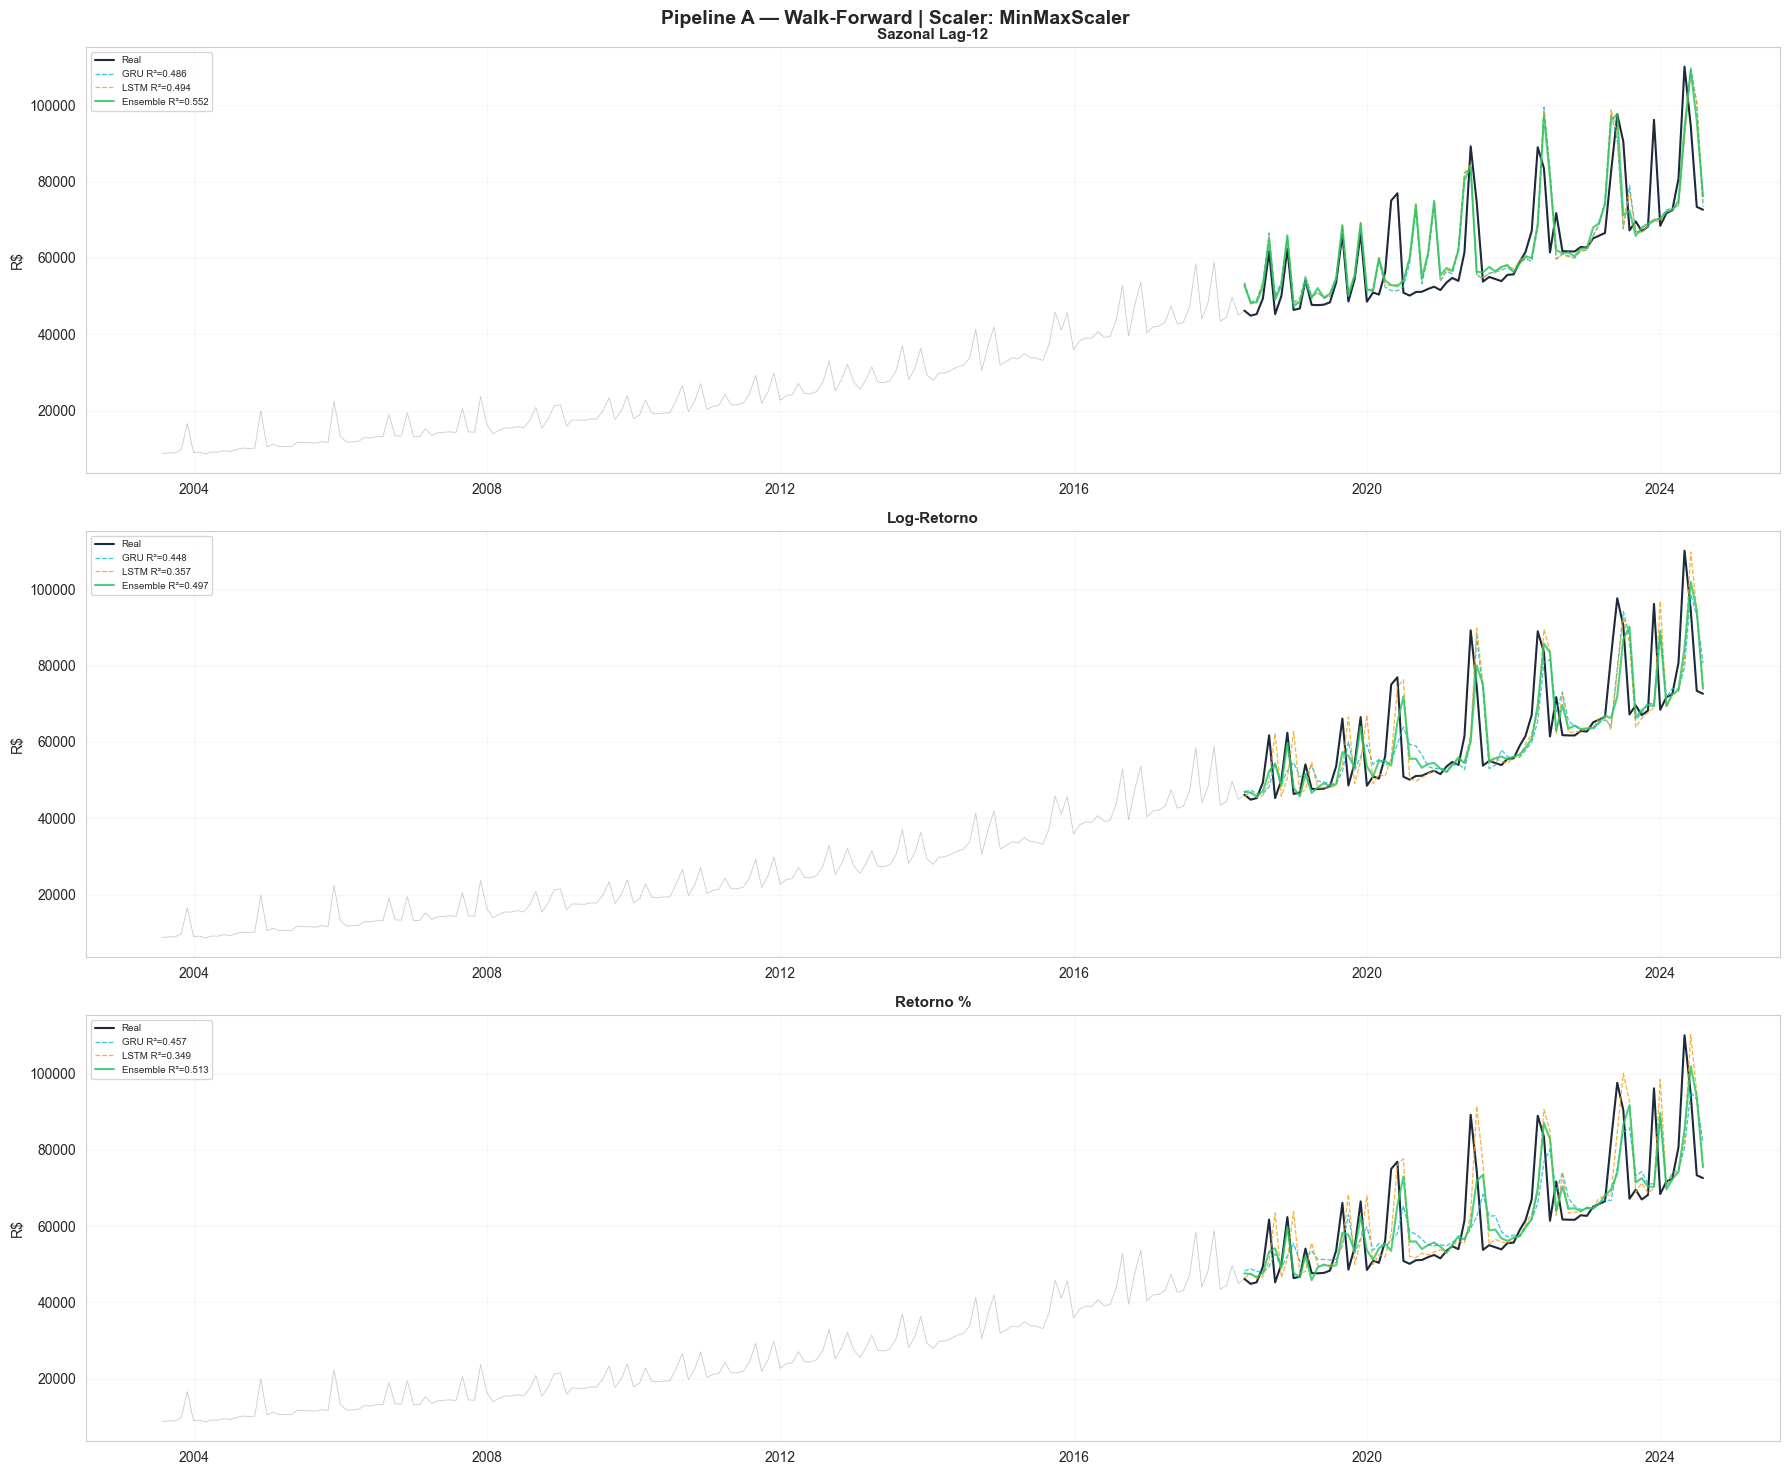

[SAVED] pA_walkforward_MinMaxScaler.png


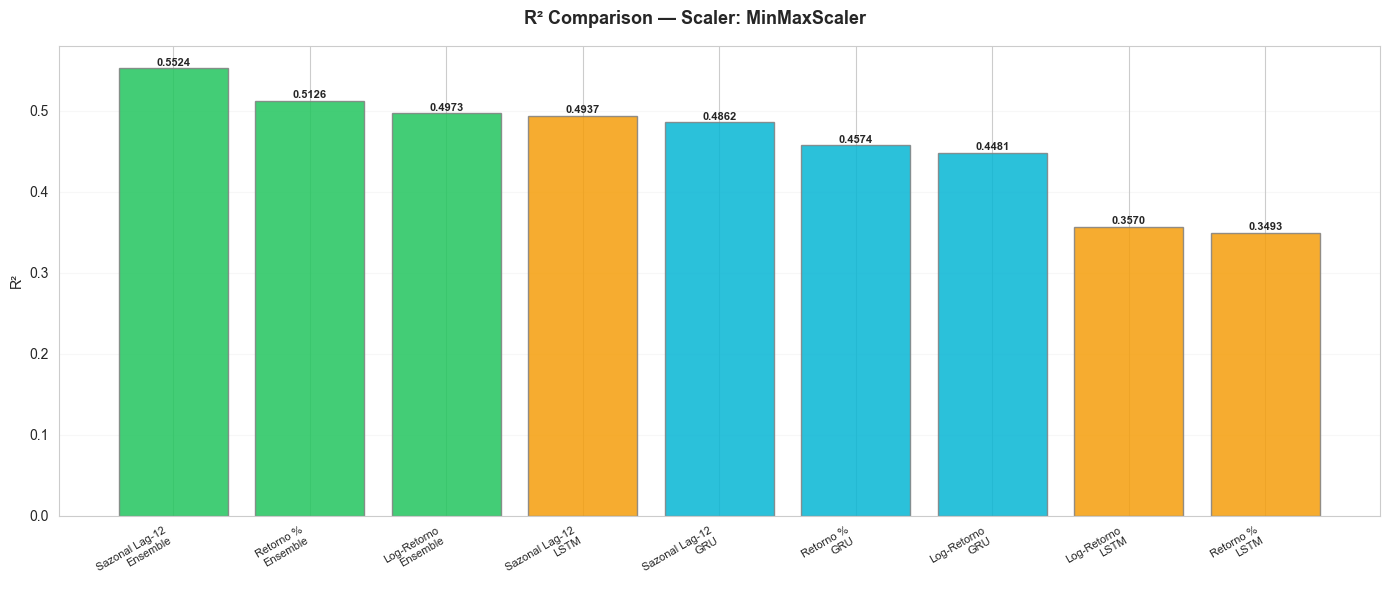

[SAVED] pA_r2_bar_MinMaxScaler.png


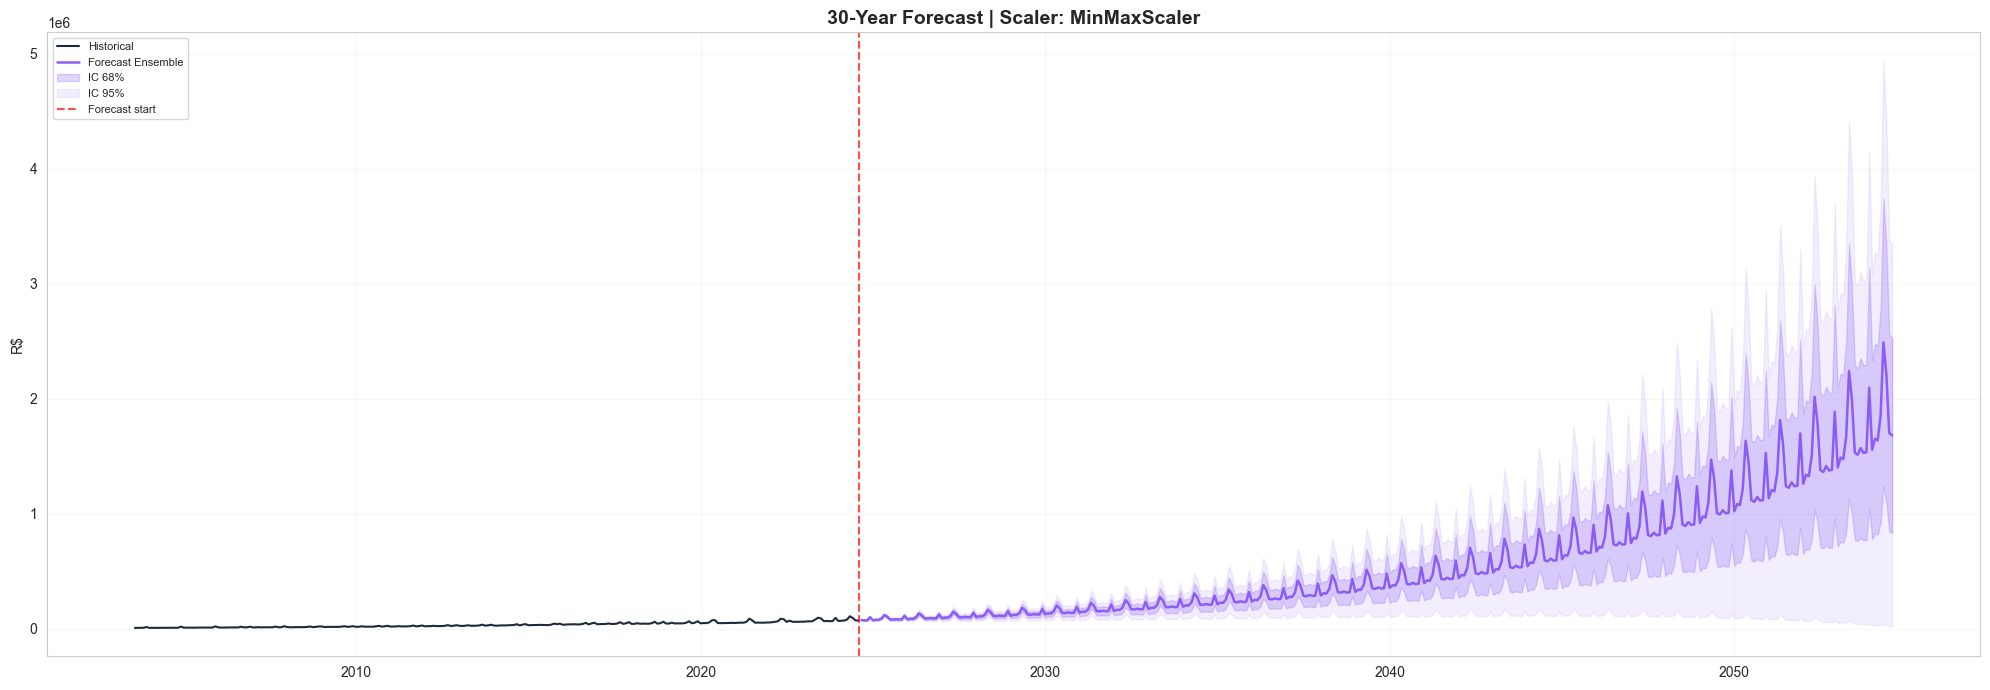

[SAVED] pA_forecast30y_MinMaxScaler.png


In [12]:
# ── Pipeline A — Visualizations ─────────────────────────────────────

def plot_pipeline_a(df, results: dict, scaler_label: str):
    if not results:
        return
    todos = results["resultados"]
    metricas = results["metricas"]
    futuro = results["futuro"]
    cores = {"GRU": "#06b6d4", "LSTM": "#f59e0b", "Ensemble": "#22c55e"}

    # ── Walk-forward series ───────────────────────────────────────────
    n_modes = len(TRANSFORMATIONS)
    fig, axes = plt.subplots(n_modes, 1, figsize=(18, 5 * n_modes))
    if n_modes == 1:
        axes = [axes]
    fig.suptitle(f"Pipeline A — Walk-Forward | Scaler: {scaler_label}",
                 fontsize=14, fontweight="bold")

    for ax, modo in zip(axes, TRANSFORMATIONS):
        res_ens = todos[modo]["Ensemble"]
        datas = df["data"].iloc[res_ens["indices"]].values
        ax.plot(df["data"], df["valores"], color="#475569", lw=0.6, alpha=0.3)
        ax.plot(datas, res_ens["real"], color="#1e293b", lw=1.5, label="Real")
        for nome in ("GRU", "LSTM", "Ensemble"):
            r = todos[modo][nome]
            d = df["data"].iloc[r["indices"]].values
            m = metricas[f"{modo}_{nome}"]
            ls = "--" if nome != "Ensemble" else "-"
            ax.plot(d, r["pred"], color=cores[nome], lw=1.5 if nome == "Ensemble" else 0.9,
                    linestyle=ls, alpha=0.8,
                    label=f"{nome} R²={m['R2']:.3f}")
        ax.set_title(_LABEL_MAP[modo], fontsize=11, fontweight="bold")
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.15)
        ax.set_ylabel("R$")

    plt.tight_layout()
    fname = f"pA_walkforward_{scaler_label}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {fname}")

    # ── R² bar chart ──────────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(14, 6))
    fig2.suptitle(f"R² Comparison — Scaler: {scaler_label}",
                  fontsize=13, fontweight="bold")
    combos = sorted(
        [(k, v["R2"], _LABEL_MAP.get(k.rsplit("_", 1)[0], k))
         for k, v in metricas.items()],
        key=lambda x: x[1], reverse=True,
    )
    xlabels = [f"{c[2]}\n{c[0].rsplit('_',1)[-1]}" for c in combos]
    r2_vals = [c[1] for c in combos]
    bar_colors = [cores.get(c[0].rsplit("_", 1)[-1], "#8b5cf6") for c in combos]
    bars = ax2.bar(range(len(combos)), r2_vals, color=bar_colors, edgecolor="gray", alpha=0.85)
    ax2.set_xticks(range(len(combos)))
    ax2.set_xticklabels(xlabels, fontsize=8, rotation=30, ha="right")
    ax2.set_ylabel("R²")
    ax2.grid(True, alpha=0.15, axis="y")
    for bar, val in zip(bars, r2_vals):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f"{val:.4f}", ha="center", fontsize=8, fontweight="bold")
    plt.tight_layout()
    fname2 = f"pA_r2_bar_{scaler_label}.png"
    plt.savefig(fname2, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {fname2}")

    # ── 30-year forecast ──────────────────────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(20, 7))
    ax3.plot(df["data"], df["valores"], color="#1e293b", lw=1.5, label="Historical")
    ax3.plot(futuro["datas"], futuro["previsoes"],
             color="#8b5cf6", lw=1.8, label="Forecast Ensemble")
    ax3.fill_between(futuro["datas"], futuro["banda_68_inf"], futuro["banda_68_sup"],
                     alpha=0.25, color="#8b5cf6", label="IC 68%")
    ax3.fill_between(futuro["datas"], futuro["banda_95_inf"], futuro["banda_95_sup"],
                     alpha=0.10, color="#8b5cf6", label="IC 95%")
    ax3.axvline(x=df["data"].iloc[-1], color="red", ls="--", alpha=0.7,
                label="Forecast start")
    ax3.set_title(f"30-Year Forecast | Scaler: {scaler_label}",
                  fontsize=14, fontweight="bold")
    ax3.set_ylabel("R$")
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.15)
    plt.tight_layout()
    fname3 = f"pA_forecast30y_{scaler_label}.png"
    plt.savefig(fname3, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {fname3}")


if pipeline_a_results:
    plot_pipeline_a(df, pipeline_a_results, SCALER_TYPE)


---
## Pipeline B — Temporal Fusion Transformer (TFT v5)


In [13]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  PIPELINE B — run_tft_pipeline()                                    ║
# ╚══════════════════════════════════════════════════════════════════════╝

def run_tft_pipeline(df_raw: pd.DataFrame) -> dict:
    """
    Cross-validation + optional Optuna + final TFT model.
    Scaler type: injected via SCALER_TYPE → apply_tft_scaling().
    """
    if not TORCH_AVAILABLE:
        print("[SKIP] PyTorch not available — skipping Pipeline B.")
        return {}

    print(f"\n{'█'*70}")
    print(f"  PIPELINE B — TFT v5")
    print(f"  Scaler: {SCALER_TYPE}")
    print(f"{'█'*70}")

    tcfg = TFT_CONFIG
    n_total = len(df_raw)
    est_len = n_total - 12   # approx after dropna in feature engineering

    # ── Cross-Validation ──────────────────────────────────────────────
    fold_results = []
    offsets = [tcfg["max_prediction_length"] * (tcfg["n_cv_folds"] - i)
               for i in range(tcfg["n_cv_folds"])]

    print(f"\n  Cross-Validation ({tcfg['n_cv_folds']} folds):")
    for fold_i, offset in enumerate(offsets, 1):
        cutoff = est_len - offset
        print(f"  Fold {fold_i}: cutoff~{cutoff}")
        try:
            metrics, *_ = train_tft_fold(
                df_raw=df_raw,
                cutoff_time_idx=cutoff,
                hidden_size=tcfg["hidden_size"],
                attention_head_size=tcfg["attention_head_size"],
                dropout=tcfg["dropout"],
                learning_rate=tcfg["learning_rate"],
                max_epochs=tcfg["max_epochs"],
                verbose=False,
            )
            fold_results.append(metrics)
            print(f"    R²={metrics['R2']:.4f}  MAPE={metrics['MAPE_%']:.2f}%")
        except Exception as exc:
            print(f"    [ERROR] {type(exc).__name__}: {exc}")

    if fold_results:
        avg = {k: np.mean([f[k] for f in fold_results]) for k in fold_results[0]}
        std = {k: np.std( [f[k] for f in fold_results]) for k in fold_results[0]}
        print(f"\n  CV mean — R²={avg['R2']:.4f} ±{std['R2']:.3f}  ")
        print(f"           MAPE={avg['MAPE_%']:.2f}% ±{std['MAPE_%']:.2f}%")

    # ── Optuna ────────────────────────────────────────────────────────
    best_hp = dict(
        hidden_size=tcfg["hidden_size"],
        attention_head_size=tcfg["attention_head_size"],
        dropout=tcfg["dropout"],
        learning_rate=tcfg["learning_rate"] or 0.003,
    )

    if tcfg.get("use_optuna") and OPTUNA_AVAILABLE:
        print(f"\n  Optuna search ({tcfg['optuna_trials']} trials)...")

        def objective(trial):
            hp = dict(
                hidden_size=trial.suggest_categorical("hidden_size", [16, 24, 32, 48]),
                attention_head_size=trial.suggest_categorical("heads", [1, 2, 4]),
                dropout=trial.suggest_float("dropout", 0.1, 0.4, step=0.05),
                learning_rate=trial.suggest_float("lr", 1e-4, 0.01, log=True),
            )
            try:
                m, *_ = train_tft_fold(
                    df_raw=df_raw,
                    cutoff_time_idx=est_len - tcfg["max_prediction_length"],
                    hidden_size=hp["hidden_size"],
                    attention_head_size=hp["attention_head_size"],
                    dropout=hp["dropout"],
                    learning_rate=hp["learning_rate"],
                    max_epochs=60,
                    verbose=False,
                )
                return m["MAPE_%"]
            except Exception:
                return 100.0

        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=tcfg["optuna_trials"],
                       show_progress_bar=True)
        best_hp.update({
            "hidden_size":         study.best_params["hidden_size"],
            "attention_head_size": study.best_params["heads"],
            "dropout":             study.best_params["dropout"],
            "learning_rate":       study.best_params["lr"],
        })
        print(f"  Best MAPE={study.best_value:.2f}%  params={best_hp}")

    # ── Final model ───────────────────────────────────────────────────
    print(f"\n  Training final model...")
    final_cutoff = est_len - tcfg["max_prediction_length"]
    final_metrics, best_tft, training_ds, raw_preds, pred_np, actuals_log = \
        train_tft_fold(
            df_raw=df_raw,
            cutoff_time_idx=final_cutoff,
            hidden_size=best_hp["hidden_size"],
            attention_head_size=best_hp["attention_head_size"],
            dropout=best_hp["dropout"],
            learning_rate=best_hp["learning_rate"],
            max_epochs=tcfg["max_epochs"],
            verbose=True,
        )

    print(f"\n  FINAL  R²={final_metrics['R2']:.4f}  "          f"MAPE={final_metrics['MAPE_%']:.2f}%  "          f"RMSE=R${final_metrics['RMSE']:,.0f}")

    return dict(
        cv_results=fold_results,
        cv_avg=avg if fold_results else {},
        best_hp=best_hp,
        final_metrics=final_metrics,
        best_tft=best_tft,
        raw_preds=raw_preds,
        pred_np=pred_np,
        actuals_log=actuals_log,
        final_cutoff=final_cutoff,
    )


# ── RUN ───────────────────────────────────────────────────────────────
pipeline_b_results = {}
if "tft" in PIPELINES_TO_RUN:
    pipeline_b_results = run_tft_pipeline(df)
else:
    print("[SKIP] Pipeline B not in PIPELINES_TO_RUN.")


[SKIP] Pipeline B not in PIPELINES_TO_RUN.


In [14]:
# ── Pipeline B — Visualizations ─────────────────────────────────────

def plot_pipeline_b(df_raw, results: dict, scaler_label: str):
    if not results:
        return
    tcfg = TFT_CONFIG
    pred_np = results["pred_np"]
    final_metrics = results["final_metrics"]
    n_q = pred_np.shape[-1]
    mid = n_q // 2

    pred_log = pred_np[:, :, mid]
    pred_reais = np.expm1(pred_log.flatten())

    n_val = tcfg["max_prediction_length"]
    reais_orig = df_raw["valores"].iloc[-n_val:].values
    pred_dates = df_raw["data"].iloc[-n_val:].values

    n = min(len(reais_orig), len(pred_reais))

    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    fig.suptitle(f"Pipeline B — TFT v5 | Scaler: {scaler_label}",
                 fontsize=14, fontweight="bold")

    ax = axes[0]
    hist_d = df_raw["data"].values[-60:-n_val]
    hist_v = df_raw["valores"].values[-60:-n_val]
    ax.plot(hist_d, hist_v, color="#1E40AF", lw=1.2, label="Historical")
    ax.plot(pred_dates[:n], reais_orig[:n], "o-", color="#059669",
            lw=2, ms=7, label="Actual")
    ax.plot(pred_dates[:n], pred_reais[:n], "s--", color="#DC2626",
            lw=2, ms=7, label="TFT Forecast")
    if n_q >= 3:
        last_b = pred_np[-1]
        q_lo = np.expm1(last_b[:, 0])
        q_hi = np.expm1(last_b[:, -1])
        n_ic = min(len(pred_dates), len(q_lo))
        ax.fill_between(pred_dates[:n_ic], q_lo[:n_ic], q_hi[:n_ic],
                        alpha=0.15, color="#DC2626", label="IC (2%–98%)")
    ax.set_title(f"R²={final_metrics['R2']:.4f}  "                 f"MAPE={final_metrics['MAPE_%']:.2f}%  "                 f"RMSE=R${final_metrics['RMSE']:,.0f}",
                 fontsize=11)
    ax.set_ylabel("R$")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

    ax2 = axes[1]
    errs = [abs(pred_reais[i] - reais_orig[i]) / reais_orig[i] * 100
            for i in range(n)]
    colors = ["#059669" if e < 5 else "#EA580C" if e < 15 else "#DC2626" for e in errs]
    ax2.bar(range(1, n + 1), errs, color=colors)
    ax2.axhline(10, color="gray", ls="--", alpha=0.5)
    for i, e in enumerate(errs):
        ax2.text(i + 1, e + 0.3, f"{e:.1f}%", ha="center", fontsize=9)
    ax2.set_xlabel("Horizon (months)")
    ax2.set_ylabel("APE %")
    ax2.set_title("Absolute % Error by Forecast Horizon")
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    fname = f"pB_tft_{scaler_label}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {fname}")

    # ── Interpretability ─────────────────────────────────────────────
    try:
        raw_preds = results["raw_preds"]
        best_tft  = results["best_tft"]
        interp = best_tft.interpret_output(raw_preds.output, reduction="sum")
        fig_i = best_tft.plot_interpretation(interp)
        plt.suptitle(f"TFT Variable Importance | {scaler_label}",
                     fontsize=12, fontweight="bold")
        plt.tight_layout()
        fname_i = f"pB_tft_interp_{scaler_label}.png"
        plt.savefig(fname_i, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"[SAVED] {fname_i}")
    except Exception as e:
        print(f"[WARN] Interpretability plot failed: {e}")


if pipeline_b_results:
    plot_pipeline_b(df, pipeline_b_results, SCALER_TYPE)


---
## Comparative Analysis
> **Workflow:** Run all cells with `SCALER_TYPE = "MinMaxScaler"`, export results.
> Then change to `SCALER_TYPE = "StandardScaler"` and re-run. Compare the two summary tables below.



  COMPARATIVE SUMMARY  [Scaler = MinMaxScaler]
    Pipeline       Scaler      Transform    Model     R2    RMSE    MAE  MAPE_%  Bias_%
A — Ensemble MinMaxScaler Sazonal Lag-12 Ensemble 0.5524  9571.0 6336.0    9.63    3.71
A — Ensemble MinMaxScaler      Retorno % Ensemble 0.5126  9987.0 6478.0    9.60    1.74
A — Ensemble MinMaxScaler    Log-Retorno Ensemble 0.4973 10143.0 6349.0    9.27    0.54
A — Ensemble MinMaxScaler Sazonal Lag-12     LSTM 0.4937 10179.0 6676.0   10.04    3.55
A — Ensemble MinMaxScaler Sazonal Lag-12      GRU 0.4862 10254.0 6716.0   10.05    3.30
A — Ensemble MinMaxScaler      Retorno %      GRU 0.4574 10537.0 7634.0   11.60    2.24
A — Ensemble MinMaxScaler    Log-Retorno      GRU 0.4481 10627.0 7342.0   11.02    1.00
A — Ensemble MinMaxScaler    Log-Retorno     LSTM 0.3570 11471.0 7560.0   11.46    1.08
A — Ensemble MinMaxScaler      Retorno %     LSTM 0.3493 11539.0 7690.0   11.83    3.47

[SAVED] master_results/comparative_MinMaxScaler.xlsx


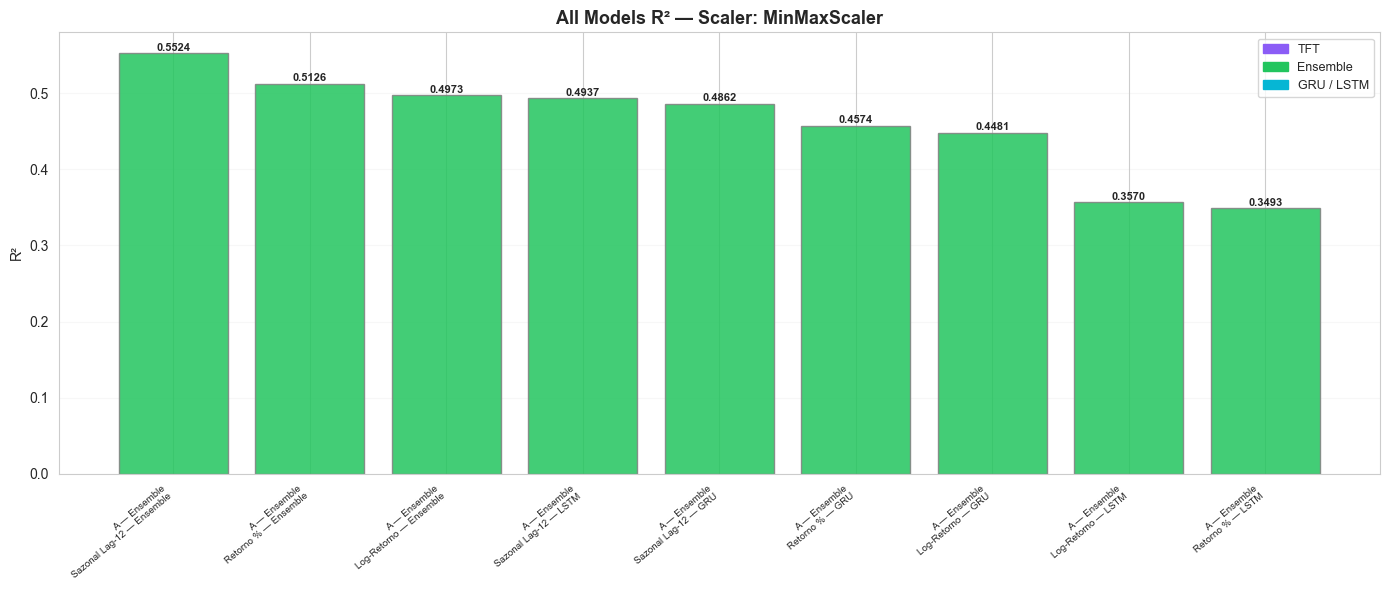

[SAVED] master_results/comparative_r2_MinMaxScaler.png


In [15]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  COMPARATIVE ANALYSIS — Unified Summary Table                       ║
# ╚══════════════════════════════════════════════════════════════════════╝

summary_rows = []

# ── Pipeline A entries ────────────────────────────────────────────────
if pipeline_a_results:
    for key, m in pipeline_a_results["metricas"].items():
        parts = key.rsplit("_", 1)
        modo_label = _LABEL_MAP.get(parts[0], parts[0])
        summary_rows.append({
            "Pipeline":   "A — Ensemble",
            "Scaler":     SCALER_TYPE,
            "Transform":  modo_label,
            "Model":      parts[1] if len(parts) > 1 else "—",
            "R2":         round(m["R2"], 4),
            "RMSE":       round(m["RMSE"], 0),
            "MAE":        round(m["MAE"], 0),
            "MAPE_%":     round(m["MAPE_%"], 2),
            "Bias_%":     round(m["Vies_%"], 2),
        })

# ── Pipeline B entry ──────────────────────────────────────────────────
if pipeline_b_results:
    m = pipeline_b_results["final_metrics"]
    summary_rows.append({
        "Pipeline":   "B — TFT v5",
        "Scaler":     SCALER_TYPE,
        "Transform":  "log1p",
        "Model":      "TFT",
        "R2":         round(m["R2"], 4),
        "RMSE":       round(m["RMSE"], 0),
        "MAE":        round(m["MAE"], 0),
        "MAPE_%":     round(m["MAPE_%"], 2),
        "Bias_%":     round(m.get("Vies_%", float("nan")), 2),
    })

if summary_rows:
    df_summary = pd.DataFrame(summary_rows)
    df_summary = df_summary.sort_values("R2", ascending=False).reset_index(drop=True)
    print(f"\n  COMPARATIVE SUMMARY  [Scaler = {SCALER_TYPE}]")
    print(df_summary.to_string(index=False))

    # Save to Excel for cross-run comparison
    out_excel = f"master_results/comparative_{SCALER_TYPE}.xlsx"
    import os; os.makedirs("master_results", exist_ok=True)
    df_summary.to_excel(out_excel, index=False)
    print(f"\n[SAVED] {out_excel}")

    # Bar chart — R² comparison
    fig, ax = plt.subplots(figsize=(14, 6))
    labels = [f"{r['Pipeline']}\n{r['Transform']} — {r['Model']}"
              for _, r in df_summary.iterrows()]
    r2_vals = df_summary["R2"].values
    bar_colors = ["#8b5cf6" if "TFT" in l else "#22c55e" if "Ensemble" in l
                  else "#06b6d4" for l in labels]
    bars = ax.bar(range(len(labels)), r2_vals, color=bar_colors,
                  edgecolor="gray", alpha=0.85)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7, rotation=40, ha="right")
    ax.set_ylabel("R²")
    ax.set_title(f"All Models R² — Scaler: {SCALER_TYPE}",
                 fontsize=13, fontweight="bold")
    ax.grid(True, alpha=0.15, axis="y")
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.4f}", ha="center", fontsize=8, fontweight="bold")
    legend_elements = [
        mpatches.Patch(color="#8b5cf6", label="TFT"),
        mpatches.Patch(color="#22c55e", label="Ensemble"),
        mpatches.Patch(color="#06b6d4", label="GRU / LSTM"),
    ]
    ax.legend(handles=legend_elements, fontsize=9)
    plt.tight_layout()
    fname_cmp = f"master_results/comparative_r2_{SCALER_TYPE}.png"
    plt.savefig(fname_cmp, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[SAVED] {fname_cmp}")
else:
    print("No pipeline results available — check PIPELINES_TO_RUN.")


In [16]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  EXPORT & SESSION SUMMARY                                            ║
# ╚══════════════════════════════════════════════════════════════════════╝

import os, json
os.makedirs("master_results", exist_ok=True)

# ── Pipeline A — CSV per transform ───────────────────────────────────
if pipeline_a_results:
    for modo in TRANSFORMATIONS:
        ref = pipeline_a_results["resultados"][modo]["Ensemble"]
        out = pd.DataFrame({"data": df["data"].iloc[ref["indices"]].values,
                             "real": ref["real"]})
        for nm in ("GRU", "LSTM", "Ensemble"):
            r = pipeline_a_results["resultados"][modo][nm]
            n = min(len(r["pred"]), len(ref["real"]))
            out[f"pred_{nm}"] = r["pred"][:n]
        out.to_csv(f"master_results/pA_{modo}_{SCALER_TYPE}.csv", index=False)

    # 30-year forecast CSV
    futuro = pipeline_a_results["futuro"]
    pd.DataFrame({
        "data":              futuro["datas"],
        "forecast_ensemble": futuro["previsoes"],
        "forecast_gru":      futuro["previsoes_gru"],
        "forecast_lstm":     futuro["previsoes_lstm"],
        "forecast_gbrt":     futuro["previsoes_gbrt"],
        "ic68_inf":          futuro["banda_68_inf"],
        "ic68_sup":          futuro["banda_68_sup"],
        "ic95_inf":          futuro["banda_95_inf"],
        "ic95_sup":          futuro["banda_95_sup"],
    }).to_csv(f"master_results/pA_forecast30y_{SCALER_TYPE}.csv", index=False)
    print(f"[SAVED] Pipeline A CSVs — scaler={SCALER_TYPE}")

# ── Session JSON ──────────────────────────────────────────────────────
session = {
    "scaler":    SCALER_TYPE,
    "window":    WINDOW_SIZE,
    "pipelines": PIPELINES_TO_RUN,
    "timestamp": datetime.now().isoformat(),
}
if pipeline_a_results:
    session["pipeline_a"] = {
        k: {"R2": v["R2"], "MAPE_%": v["MAPE_%"], "RMSE": v["RMSE"]}
        for k, v in pipeline_a_results["metricas"].items()
    }
if pipeline_b_results:
    m = pipeline_b_results["final_metrics"]
    session["pipeline_b"] = {
        "R2": m["R2"], "MAPE_%": m["MAPE_%"], "RMSE": m["RMSE"]
    }

jpath = f"master_results/session_{SCALER_TYPE}_{datetime.now():%Y%m%d_%H%M}.json"
with open(jpath, "w", encoding="utf-8") as f:
    json.dump(session, f, indent=2, ensure_ascii=False, default=str)
print(f"[SAVED] {jpath}")

# ── Print final summary ───────────────────────────────────────────────
print(f"\n{'═'*70}")
print(f"  SESSION COMPLETE")
print(f"  Scaler    : {SCALER_TYPE}")
print(f"  Window    : {WINDOW_SIZE}")
print(f"  Pipelines : {PIPELINES_TO_RUN}")
if pipeline_a_results:
    best_k, best_m = pipeline_a_results["ranking"][0]
    print(f"  Best A    : {best_k}  R²={best_m['R2']:.4f}")
if pipeline_b_results:
    bm = pipeline_b_results["final_metrics"]
    print(f"  TFT B     : R²={bm['R2']:.4f}  MAPE={bm['MAPE_%']:.2f}%")
print(f"{'═'*70}")
print("  ► To compare scalers: change SCALER_TYPE in Cell 1 and re-run.")
print(f"{'═'*70}")


[SAVED] Pipeline A CSVs — scaler=MinMaxScaler
[SAVED] master_results/session_MinMaxScaler_20260309_2238.json

══════════════════════════════════════════════════════════════════════
  SESSION COMPLETE
  Scaler    : MinMaxScaler
  Window    : 14
  Pipelines : ['ensemble_gru_lstm_gbrt']
  Best A    : sazonal_lag12_Ensemble  R²=0.5524
══════════════════════════════════════════════════════════════════════
  ► To compare scalers: change SCALER_TYPE in Cell 1 and re-run.
══════════════════════════════════════════════════════════════════════
